In [1]:
import os
import fastplotlib as fpl
import sys
import masknmf
import tifffile
import torch
import numpy as np

import matplotlib.pyplot as plt
import time
from typing import *
import pathlib
from pathlib import Path

import math
%load_ext line_profiler
%matplotlib inline
%load_ext autoreload

fastplotlib version from git (0.2.0) and __version__ (0.5.0) don't match.
No config found!
EGL says it can present to the window but not natively
Max vertex attribute stride unknown. Assuming it is 2048
Max vertex attribute stride unknown. Assuming it is 2048
Max vertex attribute stride unknown. Assuming it is 2048


Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA TITAN RTX,DiscreteGPU,Vulkan,555.42.02
❗ limited,"llvmpipe (LLVM 12.0.0, 256 bits)",CPU,Vulkan,Mesa 21.2.6 (LLVM 12.0.0)
❌,NVIDIA TITAN RTX/PCIe/SSE2,Unknown,OpenGL,3.3.0 NVIDIA 555.42.02


Max vertex attribute stride unknown. Assuming it is 2048
Max vertex attribute stride unknown. Assuming it is 2048


In [2]:
# Load the PMD mean image

In [3]:
datafile = np.load("/media/app2139/Extreme SSD/runE_compressed.npz", allow_pickle = True)

In [6]:
pmd_obj = datafile['pmd_denoise'].item()

In [8]:
pmd_obj.rescale = False
pmd_obj.to('cuda')

RFBOutputContext()

Max vertex attribute stride unknown. Assuming it is 2048
/data/home/app2139/fastplotlib/fastplotlib/graphics/features/_base.py:18: UserWarning: casting float64 array to float32
  warn(f"casting {array.dtype} array to float32")


JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
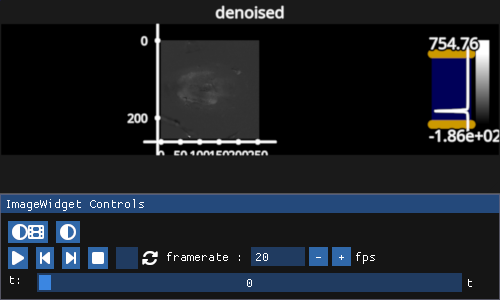

In [9]:
iw = fpl.ImageWidget(data = [pmd_obj],
                     names = ['denoised'])
iw.cmap = "gray"
iw.show()

# Next step is to pick out a binary mask that (conservatively) covers the entire brain. We can include some pixels that do not contain activity too, not a huge deal. If there is a better way to pull out this kind of binary mask, substitute it in below

In [17]:
data_dense = pmd_obj[1000:4000]

In [18]:
std_vals = np.std(data_dense, axis = 0)

In [14]:
import numpy as np
from skimage.filters import threshold_otsu
def segment_foreground_std(video, min_threshold=0.0, scale=0.5):
    """
    Segment foreground using temporal standard deviation and Otsu thresholding.
    Parameters:
        video : np.ndarray
            Array of shape (T, H, W), representing video frames.
        min_threshold : float
            Minimum threshold value to avoid overly small thresholds.
        scale : float
            Optional scaling factor to lower the Otsu threshold for more conservative masking (default 0.5).
    Returns:
        mask : np.ndarray
            Boolean array of shape (H, W), where True = foreground, False = background.
    """
    assert video.ndim == 3, "Input must be a (frames, height, width) array"
    # Compute standard deviation over time
    std_img = np.std(video, axis=0)
    # Compute Otsu threshold
    otsu_thresh = threshold_otsu(std_img)
    # Apply conservative scaling (lower threshold = more foreground)
    adjusted_thresh = max(min_threshold, scale * otsu_thresh)
    # Generate binary mask
    mask = std_img > adjusted_thresh
    return mask

In [19]:
output = segment_foreground_std(data_dense)

In [22]:
## The binary mask above will likely look a big noisy at the edges. The below code dilates the mask by 10 pixels for 
# this reason. 

import skimage.morphology
for k in range(10):
    output = skimage.morphology.dilation(output)

In [ ]:
iw = fpl.ImageWidget(data = [data_dense, output])
iw.cmap = "gray"
iw.show()

In [24]:
# Crudely zero some pixels (if applicable!! -- check which pixels need to be zero'd out above 
output[200:] = 0
output[:30] = 0

# NMF (Random) Init

In [36]:
def make_init(mask, num_comps):
    array_list = []
    for k in range(num_comps):
        x = mask.astype(np.float32) * np.random.rand(mask.shape[0], mask.shape[1])
        array_list.append(x)
    return np.array(array_list).transpose(1, 2, 0)

# Key: decide how many components to you will use. 20 seems reasonable? 

In [49]:
num_components_to_init = 20
a_init = make_init(output, num_components_to_init)

# Run NMF (everything below does not require tuning) 

In [50]:
pmd_obj = pmd_obj

num_frames, fov_dim1, fov_dim2 = pmd_obj.shape
device = 'cuda'
unfiltered_pmd_demixer = masknmf.demixing.signal_demixer.SignalDemixer(
                                                pmd_obj,
                                                device=device,
                                                frame_batch_size=500)

unfiltered_pmd_demixer.initialize_signals(is_custom=True, spatial_footprints=a_init)
unfiltered_pmd_demixer.lock_results_and_continue()

Now in demixing state


In [51]:
## Demix. Note: no support updates, no signal merging, no background model used; just Alternating Least Squares updates

num_iters = 40
## Now run demixing...
localnmf_params = {
    'maxiter':num_iters,
    'support_threshold':np.linspace(0.95, 0.7, num_iters).tolist(),
    'deletion_threshold':0.0,
    'ring_model_start_pt':num_iters + 1,
    'ring_radius':10,
    'merge_threshold':0.6,
    'merge_overlap_threshold':0.6,
    'update_frequency':num_iters + 1,
    'c_nonneg':False,
    'denoise':False,
    'plot_en': False
}

start_time = time.time()
with torch.no_grad():
    unfiltered_pmd_demixer.demix(**localnmf_params)
print(f"that took {time.time() - start_time}")
print(f"after this step {unfiltered_pmd_demixer.results.a.shape[1]} signals identified")

100%|███████████████████████████████████████████| 40/40 [00:00<00:00, 41.43it/s]


that took 1.6618707180023193
after this step 20 signals identified


In [56]:
iw = masknmf.visualization.make_demixing_video(unfiltered_pmd_demixer.results,
                                               'cuda',
                                               v_range = [-50, 50],
                                               show_histogram = True)

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
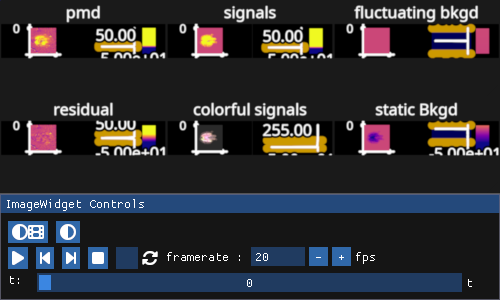

In [57]:
iw.show()

# Access the spatial (a) and temporal (c) components

In [58]:
a =  unfiltered_pmd_demixer.results.ac_array.export_a() # height x width x num_components
c = unfiltered_pmd_demixer.results.ac_array.export_c() #Frames x num components

In [59]:
c.shape

(28350, 20)

In [61]:
for k in range(a.shape[2]):
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(a[:, :,k])
    ax[1].plot(c[:, k])
    plt.show()

In [43]:
num_neurons = unfiltered_pmd_demixer.results.ac_array.export_a().shape[2]